## 데이터 전처리

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
# 1. 데이터셋 불러오기
file_path = "dataset/job_salary_prediction_dataset.csv"
df = pd.read_csv(file_path)

In [3]:
# 2. 라벨 인코딩을 적용할 컬럼 리스트
numerical_cols = ['experience_years', 'skills_count', 'certifications','salary']
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
encoders = {}

# 3. LabelEncoder 객체 생성
le = LabelEncoder()

# 4. 파일 저장 없이 df의 기존 컬럼에 바로 덮어쓰기
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# 5. 변환된 데이터 확인
df.head()


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,109413
1,5,5,0,17,9,3,0,1,0,93764
2,8,18,4,4,6,2,6,1,1,148123
3,2,19,4,13,7,2,1,2,0,189123
4,10,15,0,7,5,1,7,2,0,165069


In [4]:
joblib.dump(encoders, 'model/job_salary_prediction_labelencoders02.pkl')

['model/job_salary_prediction_labelencoders02.pkl']

In [5]:
!pip install pandas

In [6]:
!pip install numpy

## 탐색적 데이터 분석(EDA)

In [ ]:
from ydata_profiling import ProfileReport

# YData Profiling 으로 데이터 프로파일링 보고서 생성
profile = ProfileReport(df, title = 'Job Salary Profiling Report', explorative=True)

# 보고서를 HTML 파일로 저장
output_file = 'report/job_salary_profiling_report.html'
profile.to_file(output_file)
print(f"프로파일링 보고서가 생성되었습니다.: {output_file}")

c:\수업\ML_prj\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 17.49it/s]

프로파일링 보고서가 생성되었습니다.: report/job_salary_profiling_report.html


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  int64
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  int64
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  int64
 5   company_size      250000 non-null  int64
 6   location          250000 non-null  int64
 7   remote_work       250000 non-null  int64
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(10)
memory usage: 19.1 MB


In [9]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [10]:
df.describe()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,5.495124,10.005408,2.001560,9.997812,4.488544,1.997796,4.495400,0.997708,2.491928,145718.080524
std,3.456094,6.060602,1.413304,5.479288,2.873043,1.411986,2.875013,0.815790,1.706475,37407.952729
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31867.000000
25%,2.000000,5.000000,1.000000,5.000000,2.000000,1.000000,2.000000,0.000000,1.000000,119358.000000
50%,5.000000,10.000000,2.000000,10.000000,4.000000,2.000000,5.000000,1.000000,2.000000,143453.000000
75%,9.000000,15.000000,3.000000,15.000000,7.000000,3.000000,7.000000,2.000000,4.000000,169492.000000
max,11.000000,20.000000,4.000000,19.000000,9.000000,4.000000,9.000000,2.000000,5.000000,333046.000000


In [11]:
df.shape

(250000, 10)

In [12]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

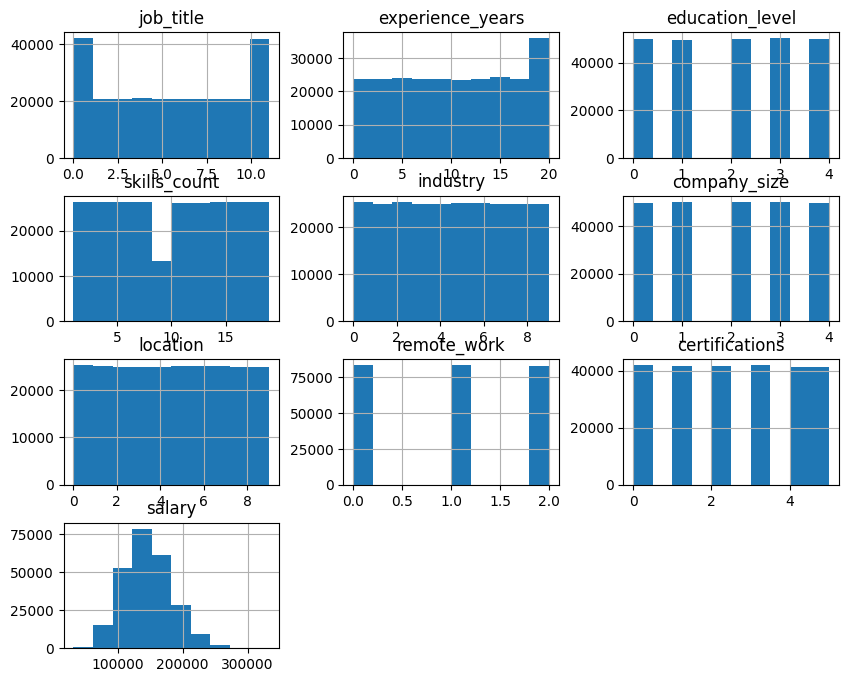

In [13]:
df.hist(figsize=(10,8))
plt.show()

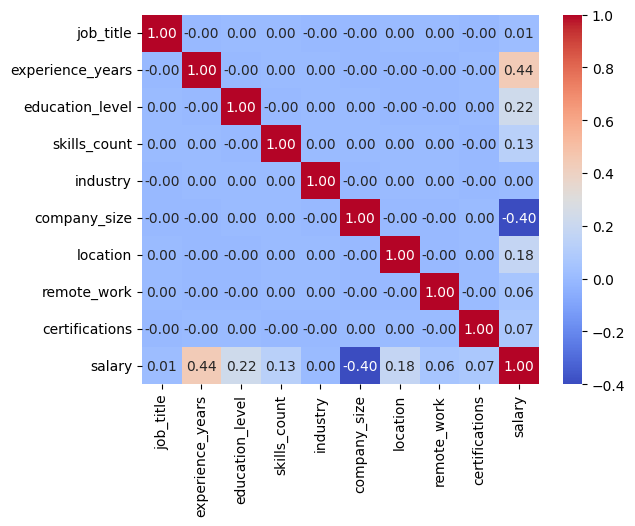

In [14]:
# 변수간 상관관계 시각화
sns.heatmap(df.corr(), annot = True, cmap='coolwarm', fmt='.2f')
plt.show()

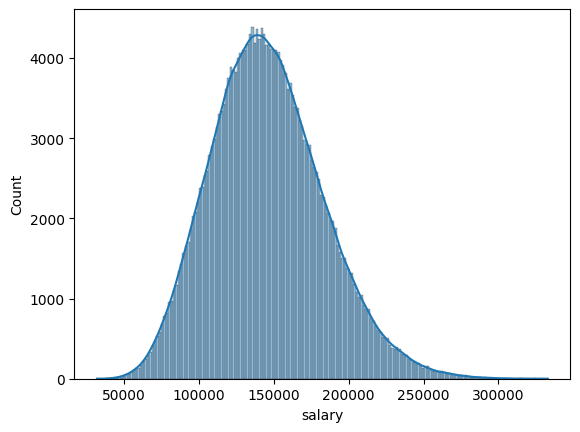

In [15]:
sns.histplot(data = df, x='salary', kde = True)
plt.show()

In [16]:
# 데이터 분리
X = df.drop('salary', axis = 1)
y = df['salary']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
# 5. 데이터 스케일링 (StandardScaler)
# 수치형 데이터를 평균 0, 표준편차 1로 맞춥니다.
scaler = StandardScaler()

# 훈련 데이터로 기준(fit)을 잡고 변환(transform)
X_train_scaled = scaler.fit_transform(X_train) 
# 테스트 데이터는 훈련 데이터의 기준을 그대로 사용하여 변환(transform)만 진행
X_test_scaled = scaler.transform(X_test) 

In [19]:
!pip install xgboost

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

In [21]:
!pip install numpy

## 모델 학습

In [ ]:
# 6. 회귀 모델 학습 및 평가
# --- 6-1. 다중 선형 회귀 (Linear Regression) ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train) # 학습
lr_pred = lr_model.predict(X_test_scaled) # 예측

# --- 6-2. 랜덤 포레스트 회귀 (Random Forest Regressor) ---
# 랜덤 포레스트는 스케일링에 큰 영향을 받지 않지만, 비교를 위해 동일하게 학습합니다.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train) # 학습
rf_pred = rf_model.predict(X_test_scaled) # 예측

#  6-3. XGBoost 회귀 (XGBRegressor) ---
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_scaled, y_train) # 학습
xgb_pred = xgb_model.predict(X_test_scaled) # 예측


In [ ]:
# 7. 성능 평가 (R2 Score와 RMSE, MAE, MAE)
def print_metrics(model_name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"[{model_name}]")
    print(f" - R² Score (설명력): {r2:.4f} (1에 가까울수록 좋음)")
    print(f" - RMSE (평균 제곱근 오차): ${rmse:,.2f}\n")
    print(f" - MAE(평균 절대 오차): ${mae:,.2f}\n")
    print(f" - MAE(평균 제곱 오차): ${mse:,.2f}\n")

In [ ]:
print_metrics("다중 선형 회귀", y_test, lr_pred)
print_metrics("랜덤 포레스트 회귀", y_test, rf_pred)
print_metrics('Xgboost 회귀', y_test, xgb_pred)

[다중 선형 회귀]
 - R² Score (설명력): 0.4560 (1에 가까울수록 좋음)
 - RMSE (평균 제곱근 오차): $27,497.63

 - MAE(평균 절대 오차): $21,740.62

 - MAE(평균 제곱 오차): $756,119,410.27

[랜덤 포레스트 회귀]
 - R² Score (설명력): 0.9691 (1에 가까울수록 좋음)
 - RMSE (평균 제곱근 오차): $6,556.19

 - MAE(평균 절대 오차): $5,181.99

 - MAE(평균 제곱 오차): $42,983,626.47

[Xgboost 회귀]
 - R² Score (설명력): 0.9745 (1에 가까울수록 좋음)
 - RMSE (평균 제곱근 오차): $5,950.99

 - MAE(평균 절대 오차): $4,746.86

 - MAE(평균 제곱 오차): $35,414,288.00



In [ ]:
# 모델 선택 (Xgboost)
xgb_model = XGBRegressor(
    n_estimators=100,     # 트리의 개수 (너무 크면 과적합)
    learning_rate=0.1,    # 학습률 (보통 0.01 ~ 0.2 사이 사용)
    max_depth=5,          # 트리의 최대 깊이
    random_state=42,      # 결과 재현성을 위한 시드 고정
    n_jobs=-1             # 모든 CPU 코어를 사용하여 학습 속도 증가
)
xgb_model.fit(X_train_scaled, y_train) # 모델 학습

xgb_pred = xgb_model.predict(X_test_scaled) # 예측
print_metrics('Xgboost 회귀', y_test, xgb_pred)

[Xgboost 회귀]
 - R² Score (설명력): 0.9745 (1에 가까울수록 좋음)
 - RMSE (평균 제곱근 오차): $5,950.99

 - MAE(평균 절대 오차): $4,746.86

 - MAE(평균 제곱 오차): $35,414,288.00



In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# 8. 튜닝할 하이퍼파라미터 그리드(Grid) 설정
# 조합해 볼 파라미터들의 리스트를 딕셔너리로 만듭니다.
param_grid = {
    'n_estimators': [100, 300, 500],     # 트리의 개수
    'learning_rate': [0.05, 0.1, 0.2], # 학습률
    'max_depth': [3, 5],    # 트리의 깊이
    'subsample':[0.8, 1],   # 각 트리에서 사용되는 피처 비율
    'colsample_bytree': [0.8 , 1], # 각 트리에서 사용되는 피쳐의 비율, 과적합 방지
    'alpha':[0, 1],     #L1 정규화(라쏘 회귀)
    'lambda':[1, 10]    #L2 정규화(릿지 회귀)
}

# 9. GridSearchCV 객체 생성
# cv=5: 교차 검증(Cross-validation)을 5번 진행
# n_jobs=-1: 사용 가능한 모든 CPU 코어 사용 (속도 향상)
# verbose=1: 학습 진행 상황 출력
grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error',  # GridSearchCV는 점수가 높을수록 좋은 모델로 간주함으로 RMSE 
    n_jobs=-1, 
    verbose=1
)
grid_search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


c:\수업\ML_prj\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [19:26:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [ ]:
# 모델 선택 (Xgboost)
print("\n최적 하이퍼파라미터:", grid_search.best_params_)
best_xgb_model = grid_search.best_estimator_
tuned_xgb_y_pred = best_xgb_model.predict(X_test_scaled)

print_metrics('Xgboost 회귀', y_test, tuned_xgb_y_pred)


최적 하이퍼파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 500}
[Xgboost 회귀]
 - R² Score (설명력): 0.9806 (1에 가까울수록 좋음)
 - RMSE (평균 제곱근 오차): $5,186.81

 - MAE(평균 절대 오차): $4,138.81

 - MAE(평균 제곱 오차): $26,903,036.00



In [ ]:
joblib.dump(best_xgb_model, 'model/job_salary_prediction_model02.pkl')

['model/job_salary_prediction_model02.pkl']

In [ ]:
joblib.dump(encoders, 'model/job_salary_prediction_labelencoders02.pkl')

['model/job_salary_prediction_labelencoders02.pkl']